# Fake and real news detection using Deep Learning Models

In [1]:
import pandas as pd


def data_extract(df, target_value):
    """
    Extracts the text and title from the dataframe and  adds a label column.
    """

    # add a target column to the dataframe
    df["label"] = target_value

    # return a df copy with text, title and label columns
    return df[["text", "title", "label"]]


DATA_CONFIG = [
    {
        "filename": "BuzzFeed_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "filename": "BuzzFeed_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "filename": "PolitiFact_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "filename": "PolitiFact_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {"filename": "Fake.csv", "extract_func": data_extract, "target_value": "FAKE"},
    {"filename": "True.csv", "extract_func": data_extract, "target_value": "TRUE"},
]


def load_merge_data(data_config):
    """
    Loads and merges the data from the given config.
    """
    dataframes = []

    for config in data_config:
        filepath = f"./data/{config['filename']}"
        df = pd.read_csv(filepath)
        df = config["extract_func"](df, config["target_value"])
        dataframes.append(df)

    # concatenate all dataframes into one
    merged_df = pd.concat(dataframes, ignore_index=True)

    return merged_df


def basic_sanity_check(df):
    """
    Performs a basic sanity check on the dataframe.
    """

    # sanity check title
    print("=" * 20)
    print("{:^20}".format("Sanity Check"))
    print("=" * 20)

    # check for missing values
    if df.isnull().values.any():
        print("Missing values found in the dataframe.")
        # remove rows with missing values
        df = df.dropna()

    # check for duplicates
    if df.duplicated().any():
        # check for duplicate rows
        duplicate_rows = df.duplicated().sum()
        print(f"Duplicate rows found: {duplicate_rows}")
        # remove duplicate rows
        df = df.drop_duplicates().reset_index(drop=True)
        print("Duplicate rows removed.")

    # check for empty strings
    if (df["text"] == "").any() or (df["title"] == "").any():
        print("Empty strings found in the dataframe.")
        # remove rows with empty strings
        df = df[(df["text"] != "") & (df["title"] != "")].reset_index(drop=True)
        print("Empty strings removed.")

    # check the shape of the dataframe
    print(f"Dataframe has {df.shape[0]} rows and {df.shape[1]} columns.")
    print(f"Dataframe has {df['label'].nunique()} unique labels.")

    print("=" * 20)


def save_data(df, path):
    """
    Saves the dataframe to a csv file.
    """
    df.to_csv(path, index=False)
    print(f"Data saved to {path}")


def generate_raw_data():
    raw_data = load_merge_data(DATA_CONFIG)
    basic_sanity_check(raw_data)
    save_data(raw_data, "./data/raw_data.csv")
    return raw_data


def load_raw_data():
    """
    Loads the raw data from the given path.
    """
    filepath = "./data/raw_data.csv"

    # check if the file exists, if not generate the raw data
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"{filepath} not found. Generating raw data...")
        df = generate_raw_data()
        print(f"Raw data generated and saved to {filepath}.")
    return df

In [2]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

# Custom stopwords (retain "not" and "can")
STOP_WORDS = set(stopwords.words("english")) - {"not", "can"}

# custom stopwords
CUSTOM_STOP_WORDS = {"reuters", "reuter"}

# Combine the two sets of stopwords
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOP_WORDS)


# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r"@\w+", "", text)  # Remove @name
    text = re.sub(r"[^a-zA-Z0-9\s\?]", "", text)  # Remove special characters except "?"
    text = re.sub(r"([^\w\s\?])", "", text)  # Remove punctuations except "?"
    text = re.sub(
        r"\s+", " ", text
    ).strip()  # Remove extra spaces and trailing whitespaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces

    # remove stopwords
    text = " ".join([word for word in text.split() if word not in STOP_WORDS])

    return text


# function to tokenize the text and remove stopwords
def tokenize_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in STOP_WORDS]
    return tokens


def lemmatize_tokens(tokens):   
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]


def preprocess_data(df):
    """
    Preprocess the data by cleaning the text and removing stopwords.
    """
    # clean title
    df["title"] = df["title"].apply(clean_text)

    # clean text
    df["text"] = df["text"].apply(clean_text)

    # create a new column called 'news', by merging the 'title' and 'text' columns
    df["news"] = df["title"] + " " + df["text"]

    # tokenize the news text and remove stopwords
    df["tokens"] = df["news"].apply(tokenize_text)

    # lemmatize the tokens
    df["tokens"] = df["tokens"].apply(lemmatize_tokens)

    # merge the tokens into a single string
    df["cleaned_news"] = df["tokens"].apply(lambda x: " ".join(x))

    # return all columns in order
    df_cleaned = df[["title", "text", "news", "tokens", "cleaned_news", "label"]]

    return df_cleaned


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import nltk
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

def load_data(df: pd.DataFrame) -> pd.DataFrame:
    # df = pd.read_csv(file_path)
    # df.drop(columns=['subject', 'date'], inplace=True)
    df['text_transformer'] = "<title>" + df['title'] + "<content>" + df['text'] + "<end>"
    df['label'] = np.where(df['label'] == "FAKE", 0, 1)
    return df[['text_transformer', 'label']]


def load_model_and_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    return tokenizer, model

def create_pipeline(model, tokenizer):
    device = 0 if torch.cuda.is_available() else -1
    return pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=device,
        max_length=512,
        truncation=True,
        padding=True
    )

def run_predictions(pipeline, texts: list, label2id: dict):
    raw_preds = pipeline(texts)
    predicted_labels = [label2id[p['label']] for p in raw_preds]
    confidences = [p['score'] for p in raw_preds]
    return predicted_labels, confidences

def evaluate_model(y_true, y_pred):
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    # plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.xticks(ticks=[0.5, 1.5], labels=["FAKE", "TRUE"])
    plt.show()

def roberta_pretrained(df):
    model_name = "hamzab/roberta-fake-news-classification"
    label2id = {"FAKE": 0, "TRUE": 1}
    # id2label = {1: "FAKE", 0: "TRUE"}

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    
    df_model = load_data(df)
    print(df_model.head(5))
    print("---"*20)
    tokenizer, model = load_model_and_tokenizer(model_name)
    pred_pipeline = create_pipeline(model, tokenizer)
    
    predicted_labels, confidences = run_predictions(pred_pipeline, df_model["text_transformer"].tolist(), label2id)
    
    df_model["predicted_label"] = predicted_labels
    df_model["confidence"] = confidences

    print(df_model.head(5))
    print("---"*20)

    # save the df_model to a csv file
    df_model.to_csv("./output/roberta_predictions.csv", index=False)
    
    evaluate_model(df_model["label"], df_model["predicted_label"])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
df = load_raw_data()
df_clean = preprocess_data(df)

Using device: cuda
                                    text_transformer  label
0  <title>proof mainstream media manipulating ele...      0
1  <title>charity clinton foundation distributed ...      0
2  <title>hillary clinton administration may enti...      0
3  <title>trumps latest campaign promise may horr...      0
4  <title>website maintenance<content>website mai...      0
------------------------------------------------------------


Device set to use cuda:0
C:\Users\u3253992\AppData\Local\Temp\ipykernel_5656\4046727910.py:84: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["predicted_label"] = predicted_labels
C:\Users\u3253992\AppData\Local\Temp\ipykernel_5656\4046727910.py:85: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["confidence"] = confidences


                                    text_transformer  label  predicted_label  \
0  <title>proof mainstream media manipulating ele...      0                1   
1  <title>charity clinton foundation distributed ...      0                0   
2  <title>hillary clinton administration may enti...      0                0   
3  <title>trumps latest campaign promise may horr...      0                0   
4  <title>website maintenance<content>website mai...      0                0   

   confidence  
0    0.998999  
1    0.822616  
2    0.999519  
3    0.999393  
4    0.999596  
------------------------------------------------------------
Accuracy: 0.8503089143865843
Precision: 0.7726671565025717
Recall: 0.9724431292768633
F1 Score: 0.8611202096298722

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.74      0.84     23692
           1       0.77      0.97      0.86     21628

    accuracy                           0.85     45320
   m

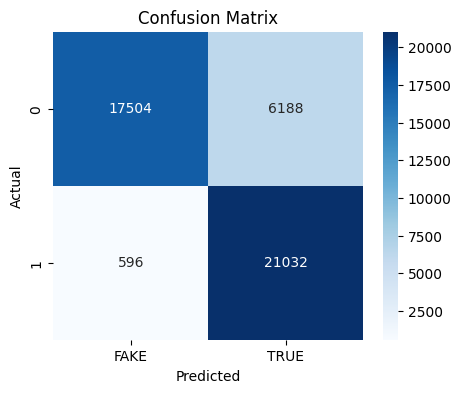

In [7]:
roberta_pretrained(df_clean.copy())

In [ ]:
# https://www.kaggle.com/code/jaskaransingh/fake-news-classification-bert-roberta

In [ ]:
# sentiment analysis on the dataset
